## Fase 2 - entrenamiento final y evaluacion sobre test (U-Net STL, simetria)

U-Net autoencoder completo (encoder + decoder), una sola fase, entrenada desde cero. Se usa la particion train/val/test original: se entrena con **train**, se monitoriza con **val** (early stopping y reduccion de LR) y se evalua una sola vez sobre **test**.

Tarea: clasificacion de simetria (3 clases). El modelo tiene dos salidas `[reconstruccion, clasificacion]`; las predicciones de clase se toman de la segunda. El balanceo de clases va por `sample_weight` (con dos salidas Keras no admite `class_weight`). Salidas: metricas finales sobre test y CSV de predicciones imagen a imagen para el estudio estadistico.

In [1]:
import os
import json
import time
import datetime as dt
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    balanced_accuracy_score, classification_report, confusion_matrix,
    roc_auc_score, ConfusionMatrixDisplay, precision_score, recall_score,
    f1_score, cohen_kappa_score,
)

os.environ["CUDA_VISIBLE_DEVICES"] = "0"

train_csv  = "/home/marc/MARIADELMAR_EXPERIMENTS/onehot_files/train_onehot.csv"
val_csv    = "/home/marc/MARIADELMAR_EXPERIMENTS/onehot_files/val_onehot.csv"
test_csv   = "/home/marc/MARIADELMAR_EXPERIMENTS/onehot_files/test_onehot.csv"
images_dir = "/home/marc/MARIADELMAR_EXPERIMENTS/dataverse_files/images"
sym_csv    = "/home/marc/MARIADELMAR_EXPERIMENTS/ham10000_shape_symmetry_ALL.csv"

IMG_SIZE    = (256, 256)
BATCH_SIZE  = 16
NUM_CLASSES = 3
TASK_NAME   = "symmetry"
class_names = ["2_ejes", "1_eje", "asimetrica"]

EPOCHS  = 60
LR_INIT = 5e-4

EXP_DIR = Path("UNet_STL") / f"exp_{dt.datetime.now():%Y-%m-%d_%H-%M}_{TASK_NAME}_FASE2_final"
EXP_DIR.mkdir(parents=True, exist_ok=True)
print(f"Experimento fase 2 (U-Net simetria) en: {EXP_DIR}")

2026-06-23 12:41:04.440744: I tensorflow/stream_executor/platform/default/dso_loader.cc:48] Successfully opened dynamic library libcudart.so.10.1


Experimento fase 2 (U-Net simetria) en: UNet_STL/exp_2026-06-23_12-41_symmetry_FASE2_final


In [2]:
# Particion original train / val / test + merge con CSV de simetria
df_train = pd.read_csv(train_csv)
df_val   = pd.read_csv(val_csv)
df_test  = pd.read_csv(test_csv)

df_sym = pd.read_csv(sym_csv).rename(columns={"image": "image_id"})[["image_id", "shape_symmetry"]]

def merge_with_sym(df, name):
    before = len(df)
    merged = df.merge(df_sym, on="image_id", how="inner")
    print(f"  {name}: merge OK, {before - len(merged)} imagenes perdidas")
    return merged

df_train = merge_with_sym(df_train, "train")
df_val   = merge_with_sym(df_val,   "val")
df_test  = merge_with_sym(df_test,  "test")
for df in (df_train, df_val, df_test):
    df["filepath"] = df["image_id"].apply(lambda x: os.path.join(images_dir, f"{x}.jpg"))

def to_onehot_sym(df):
    y = np.zeros((len(df), NUM_CLASSES), dtype="float32")
    y[np.arange(len(df)), df["shape_symmetry"].values] = 1.0
    return y

y_train = to_onehot_sym(df_train)
y_val   = to_onehot_sym(df_val)
y_test  = to_onehot_sym(df_test)
y_test_int = np.argmax(y_test, axis=1)

print(f"train: {len(df_train)}   val: {len(df_val)}   test: {len(df_test)}")


def load_image(filepath, y):
    img = tf.io.read_file(filepath)
    img = tf.image.decode_image(img, channels=3, expand_animations=False)
    img = tf.image.resize(img, IMG_SIZE)
    img = tf.cast(img, tf.float32) / 255.0
    return img, {"reconstruction_output": img, "head_sym": y}


def make_dataset(filepaths, y):
    ds = tf.data.Dataset.from_tensor_slices((filepaths, y))
    ds = ds.map(load_image, num_parallel_calls=15)
    return ds.batch(BATCH_SIZE).prefetch(50)


def make_dataset_weighted(filepaths, y, class_weight_arr, training=False):
    y_int = np.argmax(y, axis=1)
    sw    = class_weight_arr[y_int].astype("float32")

    def _load(filepath, label, sw_s, training_flag):
        img = tf.io.read_file(filepath)
        img = tf.image.decode_image(img, channels=3, expand_animations=False)
        img = tf.image.resize(img, IMG_SIZE)
        img = tf.cast(img, tf.float32)
        if training_flag:
            img = tf.image.random_flip_left_right(img)
            img = tf.image.random_flip_up_down(img)
            img = tf.image.random_brightness(img, max_delta=0.2)
            img = tf.image.random_contrast(img, lower=0.8, upper=1.2)
            img = tf.clip_by_value(img, 0.0, 255.0)
        img = img / 255.0
        targets  = {"reconstruction_output": img, "head_sym": label}
        sample_w = {"reconstruction_output": tf.constant(1.0, dtype=tf.float32),
                    "head_sym": sw_s}
        return img, targets, sample_w

    ds = tf.data.Dataset.from_tensor_slices((filepaths, y, sw))
    if training:
        ds = ds.shuffle(buffer_size=len(filepaths), reshuffle_each_iteration=True)
    ds = ds.map(lambda f, l, s: _load(f, l, s, training), num_parallel_calls=15)
    return ds.batch(BATCH_SIZE).prefetch(50)


test_ds = make_dataset(df_test["filepath"].values, y_test)

  train: merge OK, 0 imagenes perdidas
  val: merge OK, 0 imagenes perdidas
  test: merge OK, 0 imagenes perdidas
train: 6008   val: 2003   test: 2003


2026-06-23 12:41:05.464497: I tensorflow/stream_executor/platform/default/dso_loader.cc:48] Successfully opened dynamic library libcuda.so.1
2026-06-23 12:41:05.485170: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1716] Found device 0 with properties: 
pciBusID: 0000:05:00.0 name: GeForce GTX 1080 Ti computeCapability: 6.1
coreClock: 1.582GHz coreCount: 28 deviceMemorySize: 10.91GiB deviceMemoryBandwidth: 451.17GiB/s
2026-06-23 12:41:05.485197: I tensorflow/stream_executor/platform/default/dso_loader.cc:48] Successfully opened dynamic library libcudart.so.10.1
2026-06-23 12:41:05.486450: I tensorflow/stream_executor/platform/default/dso_loader.cc:48] Successfully opened dynamic library libcublas.so.10
2026-06-23 12:41:05.487606: I tensorflow/stream_executor/platform/default/dso_loader.cc:48] Successfully opened dynamic library libcufft.so.10
2026-06-23 12:41:05.487789: I tensorflow/stream_executor/platform/default/dso_loader.cc:48] Successfully opened dynamic library libcurand.so

In [3]:
def encoder_block(inputs, num_filters):
    x = tf.keras.layers.Conv2D(num_filters, 3, activation="relu", padding="same",
                               kernel_initializer="he_normal")(inputs)
    x = tf.keras.layers.Conv2D(num_filters, 3, activation="relu", padding="same",
                               kernel_initializer="he_normal")(x)
    x = tf.keras.layers.BatchNormalization()(x)
    p = tf.keras.layers.MaxPool2D(pool_size=(2, 2), strides=2)(x)
    return x, p


def decoder_block(inputs, skip_features, num_filters):
    up = tf.keras.layers.UpSampling2D(size=(2, 2))(inputs)
    x  = tf.keras.layers.Conv2D(num_filters, 2, activation="relu", padding="same",
                                kernel_initializer="he_normal")(up)
    x = tf.keras.layers.concatenate([skip_features, x], axis=3)
    x = tf.keras.layers.Conv2D(num_filters, 3, activation="relu", padding="same",
                               kernel_initializer="he_normal")(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.Conv2D(num_filters, 3, activation="relu", padding="same",
                               kernel_initializer="he_normal")(x)
    x = tf.keras.layers.BatchNormalization()(x)
    return x


def build_model():
    inputs = tf.keras.layers.Input(shape=(IMG_SIZE[0], IMG_SIZE[1], 3), name="input_image")
    c1, p1 = encoder_block(inputs, 64)
    c2, p2 = encoder_block(p1, 128)
    c3, p3 = encoder_block(p2, 256)
    c4, p4 = encoder_block(p3, 512)
    b1 = tf.keras.layers.Conv2D(1024, 3, activation="relu", padding="same",
                                kernel_initializer="he_normal")(p4)
    b1 = tf.keras.layers.BatchNormalization()(b1)
    b1 = tf.keras.layers.Conv2D(1024, 3, activation="relu", padding="same",
                                kernel_initializer="he_normal", name="bottleneck_conv")(b1)
    b1 = tf.keras.layers.BatchNormalization(name="bottleneck_bn")(b1)
    e1 = decoder_block(b1, c4, 512)
    e2 = decoder_block(e1, c3, 256)
    e3 = decoder_block(e2, c2, 128)
    e4 = decoder_block(e3, c1, 64)
    final_recon = tf.keras.layers.Conv2D(64, 3, activation="relu", padding="same",
                                         kernel_initializer="he_normal")(e4)
    final_recon = tf.keras.layers.BatchNormalization()(final_recon)
    reconstruction_output = tf.keras.layers.Conv2D(3, 1, activation="relu", padding="same",
                                                   name="reconstruction_output")(final_recon)
    x = tf.keras.layers.GlobalAveragePooling2D(name="gap")(b1)
    shared = tf.keras.layers.Dense(256, activation="relu", name="shared_dense")(x)
    shared = tf.keras.layers.Dropout(0.3, name="shared_dropout")(shared)
    out = tf.keras.layers.Dense(NUM_CLASSES, activation="softmax", name="head_sym")(shared)
    return tf.keras.Model(inputs, [reconstruction_output, out], name="STL_UNet_symmetry_autoencoder")

In [4]:
# Class weights balanceados sobre train 
y_train_int = np.argmax(y_train, axis=1)
cw = compute_class_weight(class_weight="balanced",
                          classes=np.arange(NUM_CLASSES), y=y_train_int)
print(f"class weights: {cw.round(3)}")

train_ds = make_dataset_weighted(df_train["filepath"].values, y_train, cw, training=True)
val_ds   = make_dataset_weighted(df_val["filepath"].values,   y_val,   cw, training=False)

model = build_model()
model.compile(
    optimizer=tf.keras.optimizers.Adam(LR_INIT),
    loss={"reconstruction_output": "mse", "head_sym": "categorical_crossentropy"},
    loss_weights={"reconstruction_output": 0.2, "head_sym": 0.8},
    metrics={"head_sym": "accuracy"},
)

callbacks = [
    tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=7, min_delta=0.005,
                                     restore_best_weights=True, verbose=1),
    tf.keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=3,
                                         min_lr=1e-7, verbose=1),
]
print(f"Entrenamiento U-Net autoencoder (LR={LR_INIT}, max_epochs={EPOCHS})")
t0 = time.time()
h = model.fit(train_ds, validation_data=val_ds, epochs=EPOCHS, callbacks=callbacks, verbose=2)
t_train = time.time() - t0

pd.DataFrame(h.history).to_csv(EXP_DIR / "history.csv", index=False)
model.save_weights(str(EXP_DIR / "final_weights"), save_format="tf")

class weights: [0.558 1.085 3.477]
Entrenamiento U-Net autoencoder (LR=0.0005, max_epochs=60)
Epoch 1/60


2026-06-23 12:41:08.758697: I tensorflow/stream_executor/platform/default/dso_loader.cc:48] Successfully opened dynamic library libcublas.so.10
2026-06-23 12:41:09.133684: I tensorflow/stream_executor/platform/default/dso_loader.cc:48] Successfully opened dynamic library libcudnn.so.7


376/376 - 251s - loss: 1.0703 - reconstruction_output_loss: 0.0286 - head_sym_loss: 1.3307 - head_sym_accuracy: 0.3469 - val_loss: 0.9590 - val_reconstruction_output_loss: 0.0177 - val_head_sym_loss: 1.1943 - val_head_sym_accuracy: 0.3030
Epoch 2/60
376/376 - 248s - loss: 0.8799 - reconstruction_output_loss: 0.0078 - head_sym_loss: 1.0980 - head_sym_accuracy: 0.3803 - val_loss: 0.8971 - val_reconstruction_output_loss: 0.0156 - val_head_sym_loss: 1.1175 - val_head_sym_accuracy: 0.5042
Epoch 3/60
376/376 - 248s - loss: 0.8699 - reconstruction_output_loss: 0.0075 - head_sym_loss: 1.0854 - head_sym_accuracy: 0.3946 - val_loss: 0.8680 - val_reconstruction_output_loss: 0.0087 - val_head_sym_loss: 1.0828 - val_head_sym_accuracy: 0.5397
Epoch 4/60
376/376 - 249s - loss: 0.8682 - reconstruction_output_loss: 0.0081 - head_sym_loss: 1.0832 - head_sym_accuracy: 0.4016 - val_loss: 0.9787 - val_reconstruction_output_loss: 0.0103 - val_head_sym_loss: 1.2208 - val_head_sym_accuracy: 0.2826
Epoch 5/60


              precision    recall  f1-score   support

      2_ejes     0.7380    0.5712    0.6440      1208
       1_eje     0.3320    0.2649    0.2947       604
  asimetrica     0.2235    0.6859    0.3372       191

    accuracy                         0.4898      2003
   macro avg     0.4312    0.5073    0.4253      2003
weighted avg     0.5665    0.4898    0.5094      2003



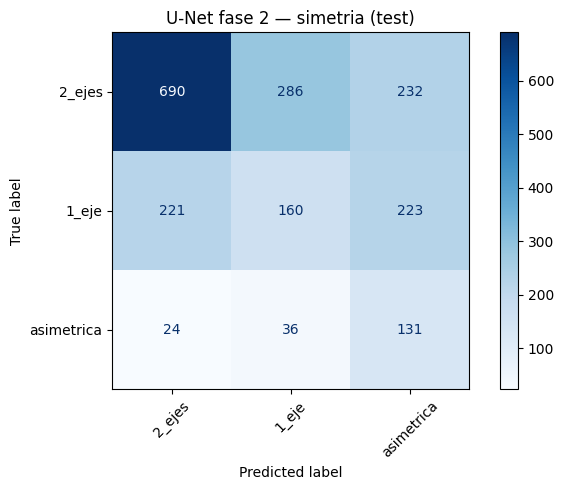


F1 macro test: 0.4253   balanced acc: 0.5073
CSV imagen a imagen guardado en:
  UNet_STL/exp_2026-06-23_12-41_symmetry_FASE2_final/predictions_STL_UNet_symmetry_FASE2.csv


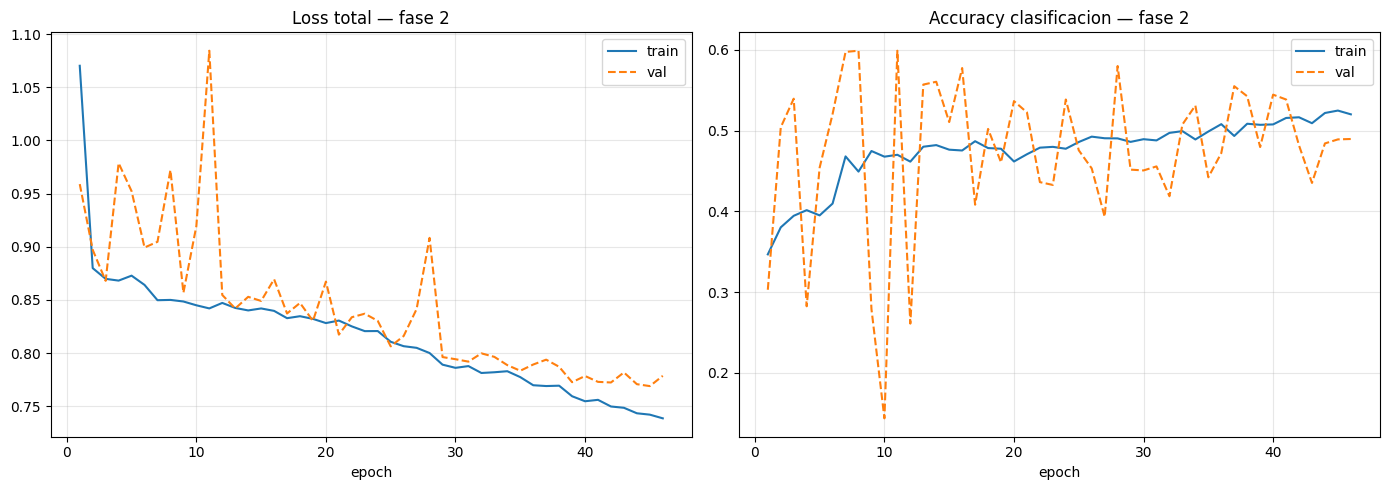

In [5]:

preds        = model.predict(test_ds, verbose=0)
y_pred_proba = preds[1]
y_pred_int   = np.argmax(y_pred_proba, axis=1)

metrics = {
    "model":                "UNet",
    "sym_acc":              float((y_test_int == y_pred_int).mean()),
    "sym_balanced_acc":     float(balanced_accuracy_score(y_test_int, y_pred_int)),
    "sym_precision_macro":  float(precision_score(y_test_int, y_pred_int, average="macro", zero_division=0)),
    "sym_recall_macro":     float(recall_score(y_test_int, y_pred_int, average="macro", zero_division=0)),
    "sym_f1_macro":         float(f1_score(y_test_int, y_pred_int, average="macro", zero_division=0)),
    "sym_f1_weighted":      float(f1_score(y_test_int, y_pred_int, average="weighted", zero_division=0)),
    "sym_kappa":            float(cohen_kappa_score(y_test_int, y_pred_int)),
    "epochs_trained":       len(h.history["loss"]),
    "time_train_s":         round(t_train, 1),
}
try:
    metrics["sym_auc_macro"] = float(roc_auc_score(
        np.eye(NUM_CLASSES)[y_test_int], y_pred_proba, multi_class="ovr", average="macro"))
except Exception:
    metrics["sym_auc_macro"] = float("nan")

(EXP_DIR / "metrics_FASE2.json").write_text(json.dumps(metrics, indent=2))
pd.DataFrame([metrics]).to_csv(EXP_DIR / "metrics_FASE2.csv", index=False)

rpt = classification_report(y_test_int, y_pred_int, target_names=class_names, digits=4)
(EXP_DIR / "classification_report_symmetry.txt").write_text(rpt)
print(rpt)

cm = confusion_matrix(y_test_int, y_pred_int)
np.save(EXP_DIR / "confusion_matrix_symmetry.npy", cm)
fig, ax = plt.subplots(figsize=(7, 5))
ConfusionMatrixDisplay(cm, display_labels=class_names).plot(
    ax=ax, cmap="Blues", xticks_rotation=45, colorbar=True)
ax.set_title("U-Net fase 2 - simetria (test)")
plt.tight_layout(); plt.savefig(EXP_DIR / "confusion_matrix_symmetry.png", dpi=120); plt.show()

print(f"\nF1 macro test: {metrics['sym_f1_macro']:.4f}   balanced acc: {metrics['sym_balanced_acc']:.4f}")

# CSV imagen a imagen
df_pred = pd.DataFrame({
    "image_id":   df_test["image_id"].values,
    "true_label": [class_names[i] for i in y_test_int],
    "pred_label": [class_names[i] for i in y_pred_int],
    "true_idx":   y_test_int,
    "pred_idx":   y_pred_int,
})
for j, c in enumerate(class_names):
    df_pred[f"prob_{c}"] = y_pred_proba[:, j]
out_csv = EXP_DIR / "predictions_STL_UNet_symmetry_FASE2.csv"
df_pred.to_csv(out_csv, index=False)
print(f"CSV imagen a imagen guardado en:\n  {out_csv}")

# Curvas de entrenamiento
hist = pd.read_csv(EXP_DIR / "history.csv")
ep = np.arange(1, len(hist) + 1)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(ep, hist["loss"], label="train"); axes[0].plot(ep, hist["val_loss"], "--", label="val")
axes[0].set_title("Loss total - fase 2"); axes[0].set_xlabel("epoch"); axes[0].grid(alpha=0.3); axes[0].legend()
ak, vak = "head_sym_accuracy", "val_head_sym_accuracy"
if ak in hist.columns:
    axes[1].plot(ep, hist[ak], label="train"); axes[1].plot(ep, hist[vak], "--", label="val")
axes[1].set_title("Accuracy clasificacion - fase 2"); axes[1].set_xlabel("epoch"); axes[1].grid(alpha=0.3); axes[1].legend()
plt.tight_layout(); plt.savefig(EXP_DIR / "training_curves_fase2.png", dpi=120); plt.show()